In [ ]:
import os
print (os.listdir())

['.config', 'sample_data']


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_science_salaries.csv to data_science_salaries.csv


In [ ]:
import pandas as pd
df = pd.read_csv("data_science_salaries.csv")
print (df.head())

        job_title experience_level employment_type work_models  work_year  \
0   Data Engineer        Mid-level       Full-time      Remote       2024   
1   Data Engineer        Mid-level       Full-time      Remote       2024   
2  Data Scientist     Senior-level       Full-time      Remote       2024   
3  Data Scientist     Senior-level       Full-time      Remote       2024   
4    BI Developer        Mid-level       Full-time     On-site       2024   

  employee_residence  salary salary_currency  salary_in_usd company_location  \
0      United States  148100             USD         148100    United States   
1      United States   98700             USD          98700    United States   
2      United States  140032             USD         140032    United States   
3      United States  100022             USD         100022    United States   
4      United States  120000             USD         120000    United States   

  company_size  
0       Medium  
1       Medium  
2    

In [ ]:
df = df.dropna()
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_" )
print ("Cleaned! Shape:", df.shape)
print(df.columns.tolist())

Cleaned! Shape: (6599, 11)
['job_title', 'experience_level', 'employment_type', 'work_models', 'work_year', 'employee_residence', 'salary', 'salary_currency', 'salary_in_usd', 'company_location', 'company_size']


In [ ]:
# Average salary by job title (top 15)
by_title =df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).head(15)
print("Top 15 Highest Paying Job Titles:")
print(by_title)

Top 15 Highest Paying Job Titles:
job_title
Analytics Engineering Manager     399880.000000
Data Science Tech Lead            375000.000000
Managing Director Data Science    280000.000000
AWS Data Architect                258000.000000
Cloud Data Architect              250000.000000
AI Architect                      232058.600000
Director of Data Science          213454.387097
Data Infrastructure Engineer      201375.416667
Data Science Director             201000.000000
ML Engineer                       198223.256637
Head of Machine Learning          198103.000000
Head of Data                      194412.000000
Principal Data Scientist          194089.600000
Machine Learning Scientist        193710.438356
Applied Scientist                 190687.711340
Name: salary_in_usd, dtype: float64


In [ ]:
# Average salary by experience level
by_exp = df.groupby ("experience_level")["salary_in_usd"].mean().sort_values(ascending=False)
print("Average Salary by Experience Level:")
print(by_exp)

Average Salary by Experience Level:
experience_level
Executive-level    189687.346457
Senior-level       162071.063581
Mid-level          119019.812537
Entry-level         84448.916814
Name: salary_in_usd, dtype: float64


In [ ]:
# Average salary by company size
by_size = df.groupby("company_size")["salary_in_usd"].mean().sort_values(ascending=False)
print("Average Salary by Company Size:")
print(by_size)

Average Salary by Company Size:
company_size
Medium    149659.386689
Large     120638.404218
Small      87687.458824
Name: salary_in_usd, dtype: float64


In [ ]:
# Average salary by remote vs onsite
by_remote = df.groupby("work_models")["salary_in_usd"].mean().sort_values(ascending=False)
print("Average Salary by Work Model:")
print(by_remote)

Average Salary by Work Model:
work_models
On-site    152600.100970
Remote     140550.137837
Hybrid      83293.502222
Name: salary_in_usd, dtype: float64


In [ ]:
# Pay equity analysis
median_salary = df["salary_in_usd"].median()
df["below_market"] = df ["salary_in_usd"] < median_salary
equity_summary = df.groupby("experience_level")["below_market"].mean() * 100
print("% of roles below market median by experience level:")
print(equity_summary)

% of roles below market median by experience level:
experience_level
Entry-level        87.787611
Executive-level    25.590551
Mid-level          69.731343
Senior-level       38.246041
Name: below_market, dtype: float64


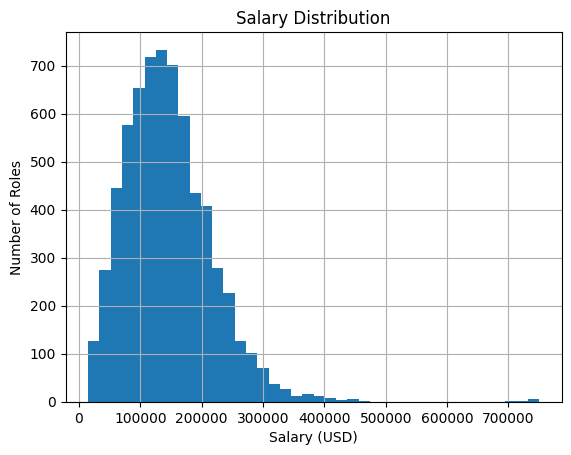

In [ ]:
import matplotlib.pyplot as plt
df["salary_in_usd"].hist(bins=40)
plt.title("Salary Distribution")
plt.xlabel("Salary (USD)")
plt.ylabel("Number of Roles")
plt.savefig("salary_distribution.png")
plt.show()

In [ ]:
from google.colab import files
df.to_csv("salaries_clean.csv", index=False)
files.download("salaries_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>